# Analyzing the Relationship Between Job satisfaction in Employees and Different Factors 


## Abstract

**complete when finished

## Authors

Team Members: Roxana Behjat, Taishi Aizawa, Rajveer Barring, Brandon Su

## Background and Prior Work

Our group is investigating the factors that drive job satisfaction, as employee satisfaction is a key indicator of organizational health, strength, and productivity. The goal is to gain a more targeted, in-depth understanding of the workplace drivers of satisfaction by investigating how job satisfaction varies across departments and its relationship to performance ratings, promotion history, and other contributing factors. Findings from this type of analysis can help inform business strategies and assist organizations in identifying departments with lower satisfaction to target. This makes our research and findings valuable, as they can be used to help companies in these kinds of movements; our original motivation was to find a way to boost organizational health, and we found this to be a good way to look into it. 



## Hypothesis


We hypothesize job satisfaction is not evenly distributed across departments and that factors related to career growth, such as promotion history, will be positively associated with satisfaction. We expect that the specific parameters we have chosen, such as benefits and employee retention, will be positively correlated with employee satisfaction. While we acknowledge that not all employee data will necessarily have a significant impact on overall employee satisfaction, we hypothesize that certain factors strongly influence how employees view their company. 


## Data

### Data overview

- **Dataset: Global Satisfaction Index Results by Agency (US Office of Personnel Management)**
  - **Dataset Name:** Employee Performance and Productivity Data by mexwell
  - **Link to the dataset:** https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data/data
  - **Number of observations:** 100,000 employees
  - **Number of variables:** 20 columns (1 datetime, 1 bool, 2 float, 4 categorical/string, 12 int)
  - **Description of the variables:**

 - `Employee_ID` (string): Unique identifier for each employee. Treated as an identifier, not a numeric variable for calculation.
- `Department` (string): Department in which the employee works, such as Sales, HR, or IT.
- `Gender` (string): Gender of the employee, such as Male, Female, or Other.
- `Age` (integer): Employee's age, ranging from 22 to 60.
- `Job_Title` (string): Role held by the employee, such as Manager, Analyst, or Developer.
- `Hire_Date` (datetime): Date the employee was hired.
- `Years_At_Company` (integer): Number of years the employee has worked at the company.
- `Education_Level` (string): Highest educational qualification, such as High School, Bachelor, Master, or PhD.
- `Performance_Score` (integer, 1–5): Employee's performance rating on a 1 to 5 scale.
- `Monthly_Salary` (float, USD): Employee's monthly salary in U.S. dollars.
- `Work_Hours_Per_Week` (integer): Number of hours the employee works per week.
- `Projects_Handled` (integer): Total number of projects handled by the employee.
- `Overtime_Hours` (integer): Total overtime hours worked by the employee in the last year.
- `Sick_Days` (integer): Number of sick days taken by the employee.
- `Remote_Work_Frequency` (integer, 0–100): Percentage of time the employee works remotely.
- `Team_Size` (integer): Number of people in the employee's team.
- `Training_Hours` (integer): Number of hours the employee spent in training.
- `Promotions` (integer): Number of promotions the employee has received during their tenure.
- `Employee_Satisfaction_Score` (float, 1.0–5.0): Employee satisfaction rating on a 1.0 to 5.0 scale.
- `Resigned` (boolean): Whether the employee has resigned from the company.



- **Shortcomings of this dataset:**
  - The data is hypothetical, not from a research study but instead artificially genrated.


In [16]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mexwell/employee-performance-and-productivity-data",
    "Extended_Employee_Performance_and_Productivity_Data.csv",
)

df_raw.head()


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


The first thing we did was move the employee ID to be the index, and then take a look at the shape of the data:

In [17]:
df_raw.set_index('Employee_ID', inplace=True)
print(f"Full dataset shape: {df_raw.shape}")
print()

print(f"  Rows (observations): {df_raw.shape[0]}")
print(f"  Columns (variables): {df_raw.shape[1]}")
print()
print(f"  Departments: {df_raw['Department'].unique()}")
print(f"  Job Titles: {df_raw['Job_Title'].unique()}")

df_raw.head()


Full dataset shape: (100000, 19)

  Rows (observations): 100000
  Columns (variables): 19

  Departments: <StringArray>
[              'IT',          'Finance', 'Customer Support',
      'Engineering',        'Marketing',               'HR',
       'Operations',            'Sales',            'Legal']
Length: 9, dtype: str
  Job Titles: <StringArray>
['Specialist',  'Developer',    'Analyst',    'Manager', 'Technician',
   'Engineer', 'Consultant']
Length: 7, dtype: str


,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
Employee_ID,,,,,,,,,,,,,,,,,,,
1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


We then looked at what each column's dtype was:

In [18]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                         str
Gender                             str
Age                              int64
Job_Title                          str
Hire_Date                          str
Years_At_Company                 int64
Education_Level                    str
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
dtype: object



We then adjusted accordingly, making each column the appropriate string, datetime, etc.

In [19]:
df_raw["Job_Title"] = df_raw["Job_Title"].astype("string")
df_raw["Department"] = df_raw["Department"].astype("string")
df_raw["Education_Level"] = df_raw["Education_Level"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw["Gender"] = df_raw["Gender"].astype("string")
df_raw['Hire_Date'] = pd.to_datetime(df_raw['Hire_Date'])

In [20]:
print("Column names and dtypes:")
print(df_raw.dtypes)
print()

Column names and dtypes:
Department                             string
Gender                                 string
Age                                     int64
Job_Title                              string
Hire_Date                      datetime64[us]
Years_At_Company                        int64
Education_Level                        string
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                     int64
Projects_Handled                        int64
Overtime_Hours                          int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                          int64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
dtype: object



We then took a look at the number of missing values in the dataset, and there are none.

Missing values per column:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values found in any column.


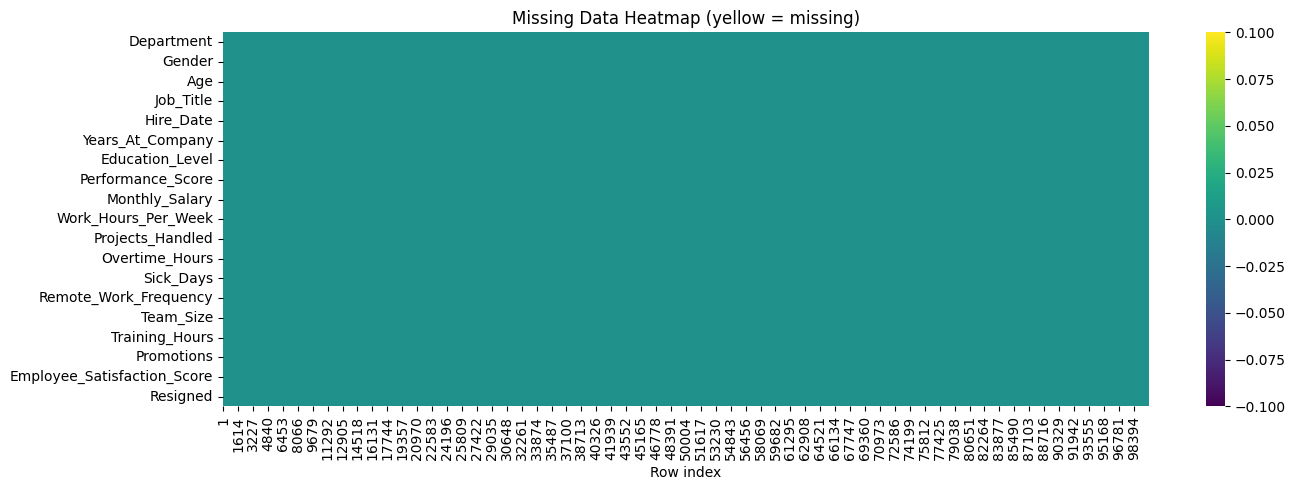


Rows with at least one missing value: 0 / 100000 (0.00%)


In [21]:
missing_counts = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print("Missing values per column:")
print(missing_summary[missing_summary['missing_count'] > 0])
print()
if missing_summary['missing_count'].sum() == 0:
    print("No missing values found in any column.")
else:
    print(f"Total missing values: {missing_summary['missing_count'].sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_raw.isnull().T, cbar=True, yticklabels=True, cmap='viridis', ax=ax)
ax.set_title('Missing Data Heatmap (yellow = missing)')
ax.set_xlabel('Row index')
plt.tight_layout()
plt.show()

rows_with_missing = df_raw.isnull().any(axis=1).sum()
print(f"\nRows with at least one missing value: {rows_with_missing} / {len(df_raw)} "
      f"({rows_with_missing / len(df_raw):.2%})")

## Results

### Exploratory Data Analysis


Before running formal statistical tests, we first explore the structure of the employee data to understand what patterns are visible in the sample. This EDA section reviews the distribution of employee satisfaction, compares satisfaction across departments, and examines whether satisfaction appears to vary with performance scores, promotion history, salary, tenure, and retention status. We also check missing values, possible outliers, and variables that may be less useful for the main research question. The goal is to identify the strongest visible patterns and limitations in the data before moving into formal analysis.

In [22]:
df_eda = df_raw.copy()

if 'Employee_ID' in df_eda.columns:
    df_eda = df_eda.set_index('Employee_ID')

satisfaction_col = 'Employee_Satisfaction_Score'
main_numeric_cols = [
    satisfaction_col,
    'Performance_Score',
    'Promotions',
    'Monthly_Salary',
    'Years_At_Company',
    'Work_Hours_Per_Week',
    'Overtime_Hours',
    'Training_Hours',
    'Projects_Handled',
    'Sick_Days',
    'Team_Size',
    'Age',
    'Remote_Work_Frequency'
]
main_numeric_cols = [col for col in main_numeric_cols if col in df_eda.columns]

summary_stats = df_eda[main_numeric_cols].describe().T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)
summary_stats

,count,mean,std,min,25%,50%,75%,max
Employee_Satisfaction_Score,100000.0,3.00,1.15,1.0,2.01,3.0,3.99,5.0
Performance_Score,100000.0,3.00,1.41,1.0,2.00,3.0,4.00,5.0
Promotions,100000.0,1.00,0.82,0.0,0.00,1.0,2.00,2.0
Monthly_Salary,100000.0,6403.21,1372.51,3850.0,5250.00,6500.0,7500.00,9000.0
Years_At_Company,100000.0,4.48,2.87,0.0,2.00,4.0,7.00,10.0
Work_Hours_Per_Week,100000.0,44.96,8.94,30.0,37.00,45.0,53.00,60.0
Overtime_Hours,100000.0,14.51,8.66,0.0,7.00,15.0,22.00,29.0
Training_Hours,100000.0,49.51,28.89,0.0,25.00,49.0,75.00,99.0
Projects_Handled,100000.0,24.43,14.47,0.0,12.00,24.0,37.00,49.0
Sick_Days,100000.0,7.01,4.33,0.0,3.00,7.0,11.00,14.0


The summary statistics show that job satisfaction is centered almost exactly at 3 on a 1 to 5 scale, with the middle half of employees between about 2.01 and 3.99. Performance scores, promotion counts, remote-work frequency, and departments are also very evenly represented, so the dataset is large but fairly balanced. Salary ranges from 3850 to 9000 per month, while tenure ranges from 0 to 10 years.

In [23]:
# Missingness table
missing_summary = pd.DataFrame({
    'missing_count': df_eda.isna().sum(),
    'missing_pct': (df_eda.isna().mean() * 100).round(2)
}).sort_values(['missing_count', 'missing_pct'], ascending=False)
missing_summary

,missing_count,missing_pct
Department,0,0.0
Gender,0,0.0
Age,0,0.0
Job_Title,0,0.0
Hire_Date,0,0.0
Years_At_Company,0,0.0
Education_Level,0,0.0
Performance_Score,0,0.0
Monthly_Salary,0,0.0
Work_Hours_Per_Week,0,0.0


In [24]:
# Basic check for outliers
outlier_rows = []
for col in main_numeric_cols:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    outlier_rows.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_pct': 100 * outlier_count / len(df_eda)
    })

outlier_summary = pd.DataFrame(outlier_rows).round(2)
outlier_summary

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,Employee_Satisfaction_Score,2.01,3.99,1.98,-0.96,6.96,0,0.0
1,Performance_Score,2.00,4.00,2.00,-1.00,7.00,0,0.0
2,Promotions,0.00,2.00,2.00,-3.00,5.00,0,0.0
3,Monthly_Salary,5250.00,7500.00,2250.00,1875.00,10875.00,0,0.0
4,Years_At_Company,2.00,7.00,5.00,-5.50,14.50,0,0.0
5,Work_Hours_Per_Week,37.00,53.00,16.00,13.00,77.00,0,0.0
6,Overtime_Hours,7.00,22.00,15.00,-15.50,44.50,0,0.0
7,Training_Hours,25.00,75.00,50.00,-50.00,150.00,0,0.0
8,Projects_Handled,12.00,37.00,25.00,-25.50,74.50,0,0.0
9,Sick_Days,3.00,11.00,8.00,-9.00,23.00,0,0.0


There are no missing values in the variables used here. The check does not flag outliers in the main numeric variables. This makes sense because many variables appear to have fixed, bounded ranges in the dataset,

satisfaction is between 1 and 5
performance is between 1 and 5
promotions are 0 to 2
and tenure is 0 to 10 years

Nuisance variables for our main question include `Employee_ID`, which is only an identifier, and `Hire_Date`, which mainly the same information as `Years_At_Company`. Demographic variables such as `Gender`, `Age`, `Education_Level`, and `Job_Title` are not the main focus of this EDA section, but they could possible matter later as background variables when interpreting department, salary, or promotion patterns. We acknowledge that these and other variables outside of this dataset could also be important for understanding employee satisfaction, but we focus on our covariates defined in the hypothesis for our analysis.

In [25]:
# Grouped summary tables for the main relationships of interest.
dept_summary = (
    df_eda.groupby('Department')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        sd_satisfaction=(satisfaction_col, 'std'),
        resigned_rate=('Resigned', 'mean'),
        mean_salary=('Monthly_Salary', 'mean'),
        median_tenure=('Years_At_Company', 'median')
    )
    .sort_values('mean_satisfaction', ascending=False)
)
dept_summary['resigned_rate'] = dept_summary['resigned_rate'] * 100
dept_summary.round(2)

,n,mean_satisfaction,median_satisfaction,sd_satisfaction,resigned_rate,mean_salary,median_tenure
Department,,,,,,,
Operations,11181,3.03,3.03,1.15,10.03,6412.31,4.0
IT,11131,3.02,3.03,1.15,9.56,6414.60,4.0
Finance,11200,3.00,2.99,1.15,10.54,6398.58,4.0
Engineering,10956,3.00,2.99,1.14,9.65,6417.25,4.0
HR,10960,3.00,3.02,1.14,10.26,6400.36,4.0
Marketing,11216,2.99,2.98,1.15,10.03,6377.86,5.0
Sales,11122,2.99,2.99,1.16,9.93,6413.15,4.0
Legal,11118,2.99,2.98,1.15,10.22,6391.28,4.0
Customer Support,11116,2.97,2.96,1.15,9.88,6403.88,4.0


In [26]:
performance_summary = (
    df_eda.groupby('Performance_Score')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        resigned_rate=('Resigned', 'mean')
    )
    .sort_index()
)
performance_summary['resigned_rate'] = performance_summary['resigned_rate'] * 100

promotion_summary = (
    df_eda.groupby('Promotions')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        resigned_rate=('Resigned', 'mean'),
        median_salary=('Monthly_Salary', 'median'),
        median_tenure=('Years_At_Company', 'median')
    )
    .sort_index()
)
promotion_summary['resigned_rate'] = promotion_summary['resigned_rate'] * 100

retention_summary = (
    df_eda.groupby('Resigned')
    .agg(
        n=(satisfaction_col, 'size'),
        mean_satisfaction=(satisfaction_col, 'mean'),
        median_satisfaction=(satisfaction_col, 'median'),
        mean_salary=('Monthly_Salary', 'mean'),
        median_tenure=('Years_At_Company', 'median'),
        mean_overtime=('Overtime_Hours', 'mean')
    )
    .sort_index()
)

print('Satisfaction by performance score')
display(performance_summary.round(2))
print('Satisfaction by promotion count')
display(promotion_summary.round(2))
print('Retention summary')
display(retention_summary.round(2))

Satisfaction by performance score


,n,mean_satisfaction,median_satisfaction,resigned_rate
Performance_Score,,,,
1,20120,2.99,2.99,10.11
2,20013,3.00,3.02,9.95
3,19999,3.00,3.00,10.10
4,19940,3.00,2.99,10.19
5,19928,3.00,2.99,9.70


Satisfaction by promotion count


,n,mean_satisfaction,median_satisfaction,resigned_rate,median_salary,median_tenure
Promotions,,,,,,
0,33296,2.99,2.99,10.04,6500.0,4.0
1,33436,3.01,3.02,10.00,6500.0,4.0
2,33268,2.99,2.98,9.99,6500.0,4.0


Retention summary


,n,mean_satisfaction,median_satisfaction,mean_salary,median_tenure,mean_overtime
Resigned,,,,,,
False,89990,3.00,3.00,6403.91,4.0,14.51
True,10010,2.99,2.99,6396.94,4.0,14.58


The department table shows only a small difference in average satisfaction between departments. Operations and IT are the highest in this sample, while Customer Support is the lowest, but all department means are still very close to 3. The performance, promotion, and retention tables show even weaker separation, where the mean and median satsfaction scores are almost identical across all groups. This suggests that any later formal tests may find small effects because the sample is very large, but the practical differences seen in EDA are not large.

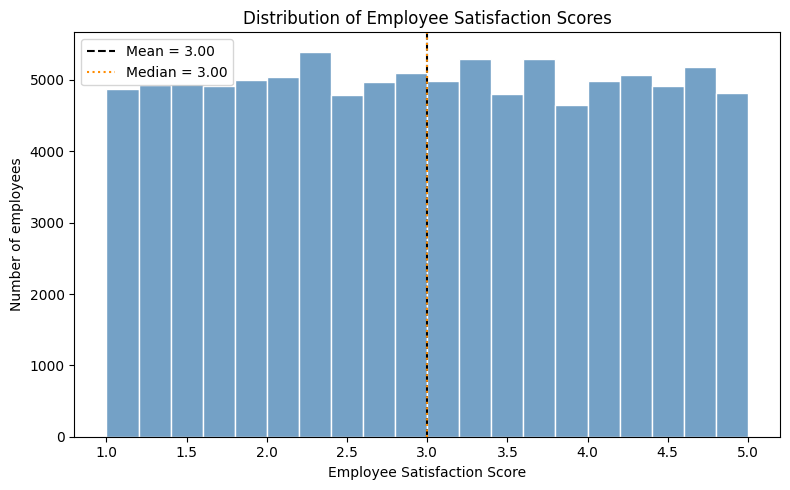

In [27]:
# Overall job satisfaction distribution.
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_eda[satisfaction_col], bins=20, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(df_eda[satisfaction_col].mean(), color='black', linestyle='--', label=f"Mean = {df_eda[satisfaction_col].mean():.2f}")
ax.axvline(df_eda[satisfaction_col].median(), color='darkorange', linestyle=':', label=f"Median = {df_eda[satisfaction_col].median():.2f}")
ax.set_title('Distribution of Employee Satisfaction Scores')
ax.set_xlabel('Employee Satisfaction Score')
ax.set_ylabel('Number of employees')
ax.legend()
plt.tight_layout()
plt.show()

This histogram is the best starting visual because it shows the outcome variable directly. Satisfaction is spread relatively evenly across the full 1 to 5 scale and is centered near 3, with identical mean and median values of 3. There is no obvious skew or pile-up at only high or low scores, so the distribution is fairly balanced. This suggests there might not be a strong driver in job satisfaction, but we investigate further along in our analysis.

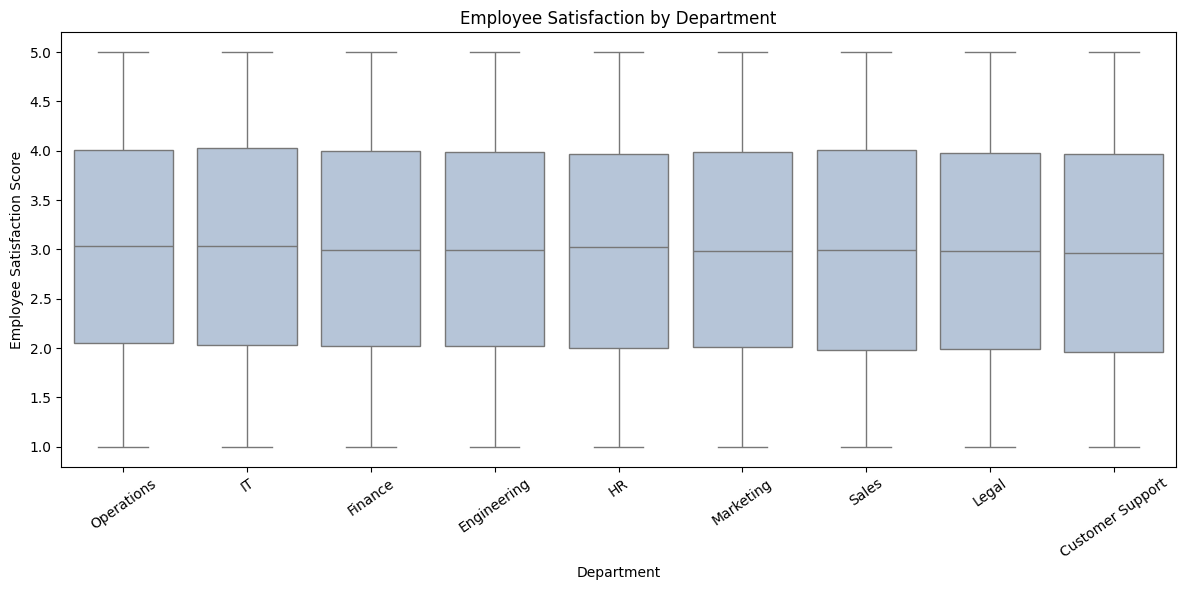

In [28]:
# Satisfaction by department.
dept_order = dept_summary.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_eda,
    x='Department',
    y=satisfaction_col,
    order=dept_order,
    color='lightsteelblue',
    ax=ax
)
ax.set_title('Employee Satisfaction by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Employee Satisfaction Score')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

This boxplot plots the satisfaction scores across different departments. Visually, the plot for each department are extremely similar, almost identical. Although technically Operations and IT have the highest mean satisfaction in the table, and Customer Support has the lowest, their plots are visually similar. The visual pattern is modest, so department may matter, but EDA does not show a large department gap by itself.

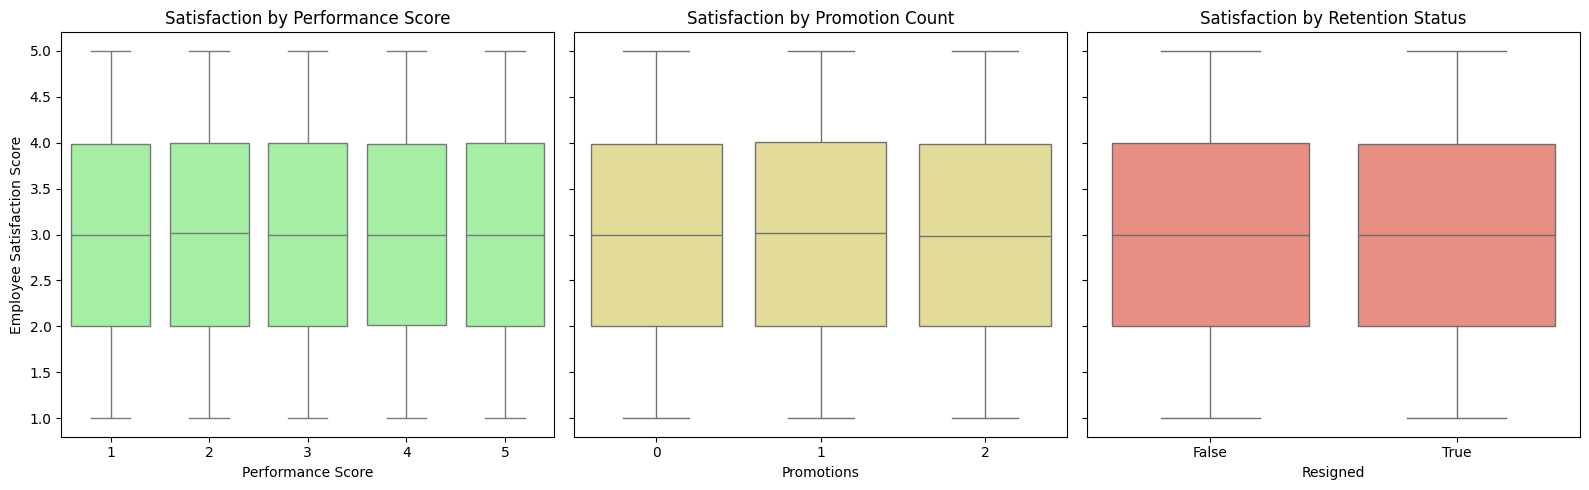

In [29]:
# Satisfaction across performance, promotions, and retention
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

sns.boxplot(data=df_eda, x='Performance_Score', y=satisfaction_col, color='palegreen', ax=axs[0])
axs[0].set_title('Satisfaction by Performance Score')
axs[0].set_xlabel('Performance Score')
axs[0].set_ylabel('Employee Satisfaction Score')

sns.boxplot(data=df_eda, x='Promotions', y=satisfaction_col, color='khaki', ax=axs[1])
axs[1].set_title('Satisfaction by Promotion Count')
axs[1].set_xlabel('Promotions')
axs[1].set_ylabel('')

sns.boxplot(data=df_eda, x='Resigned', y=satisfaction_col, color='salmon', ax=axs[2])
axs[2].set_title('Satisfaction by Retention Status')
axs[2].set_xlabel('Resigned')
axs[2].set_ylabel('')

plt.tight_layout()
plt.show()

Before formal testing, performance score, promotion history, and resignation status do not show a clear visible separation in satisfaction. Promotion count also does not show the positive pattern we expected in the hypothesis. Employees with 0, 1, or 2 promotions have nearly the same satisfaction distribution. Similarly, performance scores between 1 through 5 have visibly similar satisfaction distrubutions, alongside resignation status. This suggests that later formal tests may find small effects because of sample size, but the difference is not large enough to be obvious in EDA.

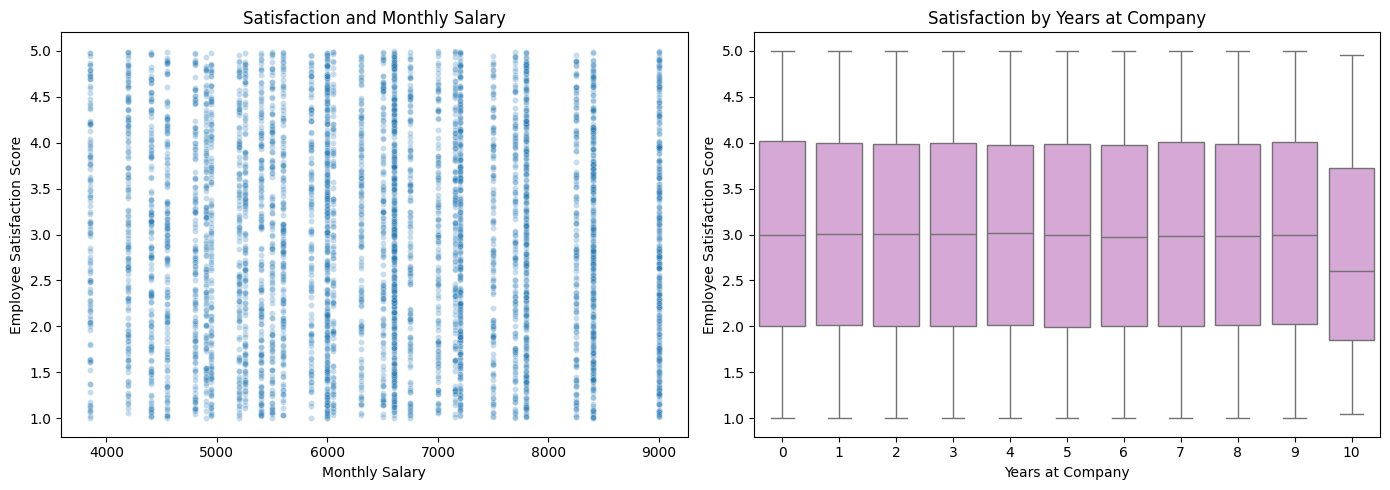

In [30]:
# Salary and tenure visuals
plot_sample = df_eda.sample(n=5000, random_state=189) if len(df_eda) > 5000 else df_eda

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=plot_sample,
    x='Monthly_Salary',
    y=satisfaction_col,
    alpha=0.25,
    s=18,
    ax=axs[0]
)
axs[0].set_title('Satisfaction and Monthly Salary')
axs[0].set_xlabel('Monthly Salary')
axs[0].set_ylabel('Employee Satisfaction Score')

sns.boxplot(
    data=df_eda,
    x='Years_At_Company',
    y=satisfaction_col,
    color='plum',
    ax=axs[1]
)
axs[1].set_title('Satisfaction by Years at Company')
axs[1].set_xlabel('Years at Company')
axs[1].set_ylabel('Employee Satisfaction Score')

plt.tight_layout()
plt.show()

The scatterplot visualizes the relationship between monthly salary and employee satisfaction. It does not show a strong visual trend, as low, middle, and high salary employees all cover nearly the full satisfaction range. The tenure boxplot visualizes the distribution of satisfaction across different levels of tenure. The tenure pattern is similarly flat across 0 to 10 years at the company, with the sole exception of 10 years at the company having a distinctly lower satisfaction level. Based on EDA alone, salary does not appear to be strong standalone explanations for satisfaction in this dataset. Although tenure does show a visible dip in satisfaction at 10 years, the rest of the tenure levels are visually similar. Further testing is needed to determine whether the 10-year tenure group is a significant indicator of lower satisfaction.

### Previous Analysis Done


## Results and Takeaways



### Potential Limitations and Shortcomings